# Introduction to Computer Vision

Computer vision is a field of artificial intelligence focused on analyzing and understanding the content of images and videos, aiming to emulate human visual capabilities. Its main goal is to automatically extract semantic information from the visual world.

## Core Objective

Computer vision seeks to transform raw visual data into meaningful insights: objects, scenes, movements, relationships, and anomalies. This enables systems to “see” and “interpret” in order to make decisions, monitor processes, or assist professionals in critical domains.


## Domains and Applications

| Domain | Examples |
|---|---|
| Object Recognition | Identifying objects or people in an image |
| Autonomous Driving | Recognizing traffic signs, pedestrians, lanes |
| Medical Diagnostics | Automated analysis of X-rays, CT scans, ultrasounds |
| Security and Biometrics | Facial recognition or fingerprint analysis |
| Industry | Quality control, automated visual inspection |

## Typical Tasks in Computer Vision

- **Classification:** Assigning a label to the entire image (e.g., “cat”, “car”).
- **Detection:** Locating objects with bounding boxes.
- **Semantic Segmentation:** Labeling each pixel with a class (e.g., road, pedestrian, sign).
- **Instance Segmentation:** Separating individual instances of the same class.
- **Pose Estimation and Tracking:** Reconstructing body poses or tracking objects over time.
- **3D Reconstruction and Depth Estimation:** Inferring geometry and depth maps from images.

## Common Challenges

- **Real-world variability:** Lighting, occlusions, perspective, noise, and distortions.
- **Generalization:** Stable performance on unseen data and across domains.
- **Data annotation:** Labeling costs, imbalance, quality, and bias.
- **Efficiency:** Computational demands and latency for real-time applications.
- **Robustness and safety:** Resistance to adversarial attacks and reliability in critical scenarios.

## Technologies and Tools

- **Convolutional Neural Networks (CNNs):** Backbone for visual feature extraction.
- **Vision Transformers (ViT):** Attention-based architectures for image data.
- **Frameworks:** PyTorch, TensorFlow, OpenCV for prototyping and deployment.
- **Datasets:** ImageNet, COCO, Cityscapes, OpenImages for training and evaluation.

### Images and Tensors in Computer Vision

In computer vision workflows, images are typically loaded as **multidimensional arrays or tensors**.  
- For example, a 2D grayscale image of size `28 × 28` can be represented as a 2D array with shape `(28, 28)`.  
- A color image of the same size is usually represented as a 3D array with shape `(28, 28, 3)`, where the extra dimension corresponds to the three color channels stored as a tuple `(R, G, B)`.  It may be also represented as 3 2d matrix stacked on each other one for each color depends on you rapresentation.
- A video can be represented as a 4D tensor, following the logic that it is a **stack of frames**. For instance, `(num_frames, height, width, channels)`.

This tensor-based representation allows models to efficiently process and learn from visual data by treating images and videos as structured numerical arrays.


### Here we can see an example of matrices and images:

Image :
 [[[147 143 161]
  [145 113 132]
  [155 211 228]
  [205  98 110]]

 [[145 113 132]
  [136   0  21]
  [185 212  87]
  [186 214  58]]

 [[223 199 174]
  [220 157 105]
  [192 208  44]
  [181 230  29]]

 [[225 167  74]
  [255 162  26]
  [255 127  39]
  [147 143 161]]]


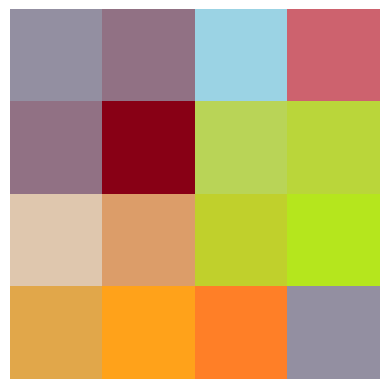

'gray_img = img.convert("L")'

In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("test_img.png") # load image with rgba channels(red, green, blue, trasparency)
img_rgb = img.convert("RGB") # convert to rgb(discard transparency)
img_array = np.array(img_rgb) # convert to numpy array

print("Image :\n", img_array)


plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to grayscale ofen used in computer vision
"""gray_img = img.convert("L")"""

# Computer Vision: From Images to Features

Modern neural networks do not interpret raw pixels directly. Instead, they learn to build **representations** — called **features** — at different levels of abstraction. These features allow the model to understand visual content in a structured and hierarchical way.


## 🧠 Levels of Feature Abstraction

| Level | Feature Type         | What It Represents                              | Visual Examples                          |
|-------|----------------------|--------------------------------------------------|-------------------------------------------|
| Low   | Low-level features   | Edges, corners, textures, color gradients        | Horizontal/vertical lines, sharp contours |
| Mid   | Mid-level features   | Object parts or combinations of patterns         | Eyes, wheels, windows, petals             |
| High  | High-level features  | Complete objects or abstract concepts            | Human face, car, flower, landscape        |


## 🔍 Why It Matters

- **Low-level features** help detect basic shapes and textures.
- **Mid-level features** capture semantic structures like object parts.
- **High-level features** enable recognition of full objects and concepts.

This layered approach is what makes deep learning so powerful in computer vision: it builds understanding from the ground up.

## 🧪 Example: CNN Feature Maps

In a convolutional neural network (CNN):

- Early layers detect edges and textures.
- Intermediate layers respond to object parts.
- Final layers activate for full objects or categories.

> ✅ Tip: You can visualize feature maps using tools like `torchvision`, `matplotlib`, or `TensorBoard` to see how your model “sees” the image at each stage. 

### ⚠️ Limitations of MLPs for Images

- **High dimensional input:**  
  Even a small grayscale image of size `28 × 28` (like those in MNIST) requires an input layer with **784 neurons**, not counting hidden layers. For larger images, the input size becomes unmanageable.

- **Loss of spatial structure:**  
  Flattening the image into a 1D vector destroys the **spatial relationships** between pixels. MLPs treat each pixel independently, ignoring patterns like edges, textures, or object parts.

- **Poor generalization:**  
  Without spatial awareness, MLPs struggle to learn features that generalize across translations, rotations, or scale changes. They lack the inductive bias needed for visual tasks.

- **Parameter explosion:**  
  Fully connected layers scale poorly with input size, leading to **millions of parameters** for even modest image resolutions. This increases overfitting risk and computational cost.

### What Is A Cnn (Convolutionary Neural Network)?

The cnn is a model that is built for various spatial, related tasks, lik

CNNs excel at:
- Local pattern detection (edges, motifs, transitions)
- Translation invariance (robust to shifts and distortions)
- Parameter efficiency (shared weights reduce overfitting)

Any data that can be represented as a grid — whether pixels, spectrograms, or encoded sequences — can benefit from CNNs.

The cnn has some key elements of it's architecture worth of explanation:
- **The Convolution :**
  The cnn apply a filter (a matrix or a tensor, depending on the context) called Kernel, that multiply a section of the oringinal image(that is a multidimensional array) in a new representation of the image called feature map then relu is applied

- **The Pooling :**
  Pooling is a reduction operation applied to feature maps. Its purpose is to reduce the spatial dimensions while retaining the most important information. This makes the network more efficient and robust to small translations or distortions in the input.

  - **Max pooling:** selects the maximum value within each region (captures the strongest activation).
  - **Average pooling:** computes the average value within each region (smooths activations).
  - **Benefits:**
    - Reduces computational cost
    - Prevents overfitting by limiting parameters
    - Provides translation invariance

- **The fully connected layer :**
  After convolution and pooling, the resulting feature maps are **flattened** into a 1D vector and passed through one or more fully connected (dense) layers.

- **Role:**
  - Combines extracted features to perform high-level reasoning
  - Each neuron connects to all outputs of the previous layer
  - Often followed by activation functions (ReLU, softmax, sigmoid)

Often is used for the final reasoning on the representation of the original image.

Usually a Cnn is built with layers in this order: 
Input-Convolution(one or more layers)and ReLU-Pooling(One or more)-(Optional) More convolution (ReLU) + pooling blocks-Flattening 1d-Fully Connected Layer-Softmax(or else)

### Stride

Definition: Stride controls how far the convolution window shifts after each operation. It is an integer hyperparameter.
Effect on Output Size: Larger strides → smaller output feature maps. Smaller strides → larger output feature maps (closer to input size).
Formula for output dimension (without padding):


### Implementing The Convolution

Image shape: (9, 9, 3)


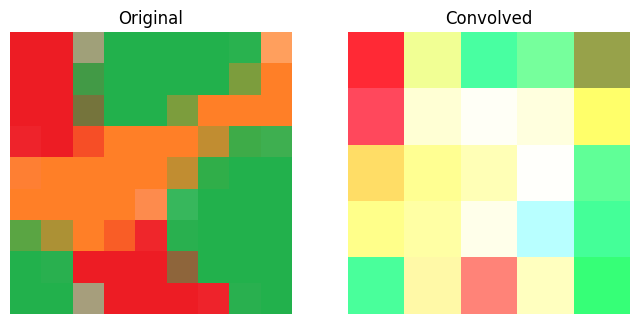

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def convolve(image, kernel, stride=1):
    h, w, c = image.shape
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    # Pad image to handle borders
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant')

    # Compute output dimensions based on stride
    out_h = (h + 2*pad_h - k_h) // stride + 1
    out_w = (w + 2*pad_w - k_w) // stride + 1
    output = np.zeros((out_h, out_w, c))

    # Apply convolution per channel
    for ch in range(c):
        for i in range(0, h, stride):
            for j in range(0, w, stride):
                region = padded[i:i+k_h, j:j+k_w, ch]
                output[i//stride, j//stride, ch] = np.sum(region * kernel)

    # Clip values to valid range [0,255]
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

# Load image
image_matrix = Image.open("test_img_2.png").convert("RGB")
image_matrix = np.array(image_matrix)
print("Image shape:", image_matrix.shape)  # (height, width, channels)

# Split and recombine channels (not strictly necessary, but consistent)
R = image_matrix[:, :, 0]
G = image_matrix[:, :, 1]
B = image_matrix[:, :, 2]
image_matrix = np.stack((R, G, B), axis=-1)

# Example kernel (random or edge detection)
kernel = np.random.rand(3, 3)  # try also [[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]

# Apply convolution
convolved_image = convolve(image_matrix, kernel, 2)

# Show result
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(image_matrix); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(convolved_image); plt.title("Convolved"); plt.axis("off")
plt.show()   

### Padding

Usually the kernel "visit" more often during "exploration" the internal pixels, and less often border pixels, to avoid this we add an extra layer of virtual pixels often setted to 0, of course in the correct dimension. 



In [3]:
padded_image_matrix = np.pad(image_matrix, ((1, 1), (1, 1), (0, 0)), mode='constant')
print("Padded Image Matrix Shape:", padded_image_matrix.shape)

Padded Image Matrix Shape: (11, 11, 3)


# Pooling 

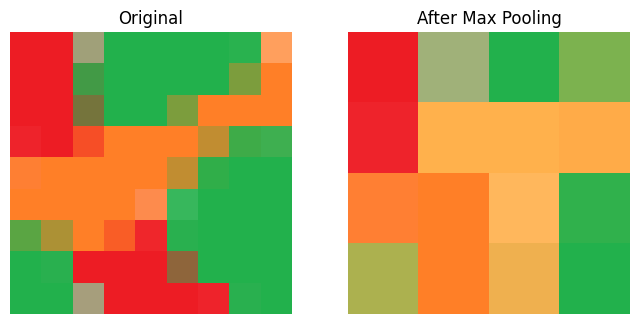

Original shape: (9, 9, 3)
Pooled shape  : (4, 4, 3)


In [4]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def max_pooling(image, pool_size=2, stride=2):
    h, w, c = image.shape
    out_h = h // stride
    out_w = w // stride
    
    # Output feature map
    output = np.zeros((out_h, out_w, c))
    
    for ch in range(c):
        for i in range(0, h - pool_size + 1, stride):
            for j in range(0, w - pool_size + 1, stride):
                region = image[i:i+pool_size, j:j+pool_size, ch]
                output[i//stride, j//stride, ch] = np.max(region)
    
    return output.astype(np.uint8)

# Load image
image_matrix = Image.open("test_img_2.png").convert("RGB")
image_matrix = np.array(image_matrix)

# Apply pooling
pooled_image = max_pooling(image_matrix, pool_size=2, stride=2)

# Show original vs pooled
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(image_matrix); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(pooled_image); plt.title("After Max Pooling"); plt.axis("off")
plt.show()

print("Original shape:", image_matrix.shape)
print("Pooled shape  :", pooled_image.shape)
